# CVAC - Consensus Vulnerability Assessment and Confidence Framework
## A Voting-Based System for Combining Multiple Vulnerability Scoring Systems
### Group 04 Project Implementation

# STEP 1: Configure Matplotlib & Install Libraries

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print('='*70)
print('STEP 1: INSTALLING REQUIRED LIBRARIES')
print('='*70)
print('\nSetting up matplotlib for inline display...')

import subprocess
import sys

print('Installing required packages...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                      'pandas', 'numpy', 'matplotlib', 'seaborn',
                      'scikit-learn', 'openpyxl', 'scipy'])

print('✓ All libraries installed successfully!\n')

STEP 1: INSTALLING REQUIRED LIBRARIES

Setting up matplotlib for inline display...
Installing required packages...
✓ All libraries installed successfully!



# STEP 2: Import Libraries

In [2]:
print('='*70)
print('STEP 2: IMPORTING LIBRARIES')
print('='*70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')
import os
import zipfile

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('✓ All libraries imported successfully!\n')

STEP 2: IMPORTING LIBRARIES
✓ All libraries imported successfully!



# STEP 3: Upload CSV Datasets

In [3]:
print('='*70)
print('STEP 3: UPLOAD YOUR CSV FILES')
print('='*70)
print('\nYou need to upload 2 files:')
print('1. known_exploited_vulnerabilities.csv')
print('2. PT-all-scores-all-approaches.csv')

try:
    from google.colab import files
    uploaded = files.upload()
    kev_file = [f for f in uploaded.keys() if 'known' in f.lower() or 'kev' in f.lower()][0]
    scores_file = [f for f in uploaded.keys() if 'scores' in f.lower()][0]
    print(f'✓ KEV file loaded: {kev_file}')
    print(f'✓ Scores file loaded: {scores_file}\n')
except:
    print('Error uploading files.\n')
    exit()

STEP 3: UPLOAD YOUR CSV FILES

You need to upload 2 files:
1. known_exploited_vulnerabilities.csv
2. PT-all-scores-all-approaches.csv


Saving known_exploited_vulnerabilities.csv to known_exploited_vulnerabilities.csv
Saving PT-all-scores-all-approaches.csv to PT-all-scores-all-approaches.csv
✓ KEV file loaded: known_exploited_vulnerabilities.csv
✓ Scores file loaded: PT-all-scores-all-approaches.csv



# STEP 4: Load Data

In [4]:
print('='*70)
print('STEP 4: LOADING DATA')
print('='*70)

kev_data = pd.read_csv(kev_file)
scores_data = pd.read_csv(scores_file)

print(f'\nKEV Dataset Shape: {kev_data.shape}')
print(f'Columns: {list(kev_data.columns)}')
print(f'\nScoring Systems Dataset Shape: {scores_data.shape}')
print(f'Columns: {list(scores_data.columns)}\n')

STEP 4: LOADING DATA

KEV Dataset Shape: (1226, 11)
Columns: ['cveID', 'vendorProject', 'product', 'vulnerabilityName', 'dateAdded', 'shortDescription', 'requiredAction', 'dueDate', 'knownRansomwareCampaignUse', 'notes', 'cwes']

Scoring Systems Dataset Shape: (600, 15)
Columns: ['CVEId', 'CVSSBaseVector', 'CVSSBaseScore', 'CVSSLowEnvironmentVector', 'CVSSLowEnvironmentScore', 'CVSSMediumEnvironmentVector', 'CVSSMediumEnvironmentScore', 'CVSSHighEnvironmentVector', 'CVSSHighEnvironmentScore', 'ExploitabilityIndex', 'SSVCScoreLow', 'SSVCScoreMedium', 'SSVCScoreHigh', 'EPSSScore', 'CWEs']



# STEP 5: Data Preprocessing

In [5]:
print('='*70)
print('STEP 5: DATA PREPROCESSING')
print('='*70)

kev_data.columns = kev_data.columns.str.strip().str.lower()
scores_data.columns = scores_data.columns.str.strip().str.lower()

kev_cve_col = [col for col in kev_data.columns if 'cve' in col][0]
scores_cve_col = [col for col in scores_data.columns if 'cve' in col][0]

print(f'\nIdentified CVE columns in both datasets')

exploited_cves = set(kev_data[kev_cve_col].unique())
scores_data['is_exploited'] = scores_data[scores_cve_col].isin(exploited_cves).astype(int)

print(f'Total unique exploited CVEs: {len(exploited_cves)}')
print(f'Exploited CVEs in scores dataset: {scores_data["is_exploited"].sum()}\n')

STEP 5: DATA PREPROCESSING

Identified CVE columns in both datasets
Total unique exploited CVEs: 1226
Exploited CVEs in scores dataset: 13



# STEP 6: Normalize Scores to 0-1 Scale

In [6]:
print('='*70)
print('STEP 6: NORMALIZING SCORES TO 0-1 SCALE')
print('='*70)

def normalize_score(value, min_val, max_val):
    if pd.isna(value):
        return np.nan
    return (value - min_val) / (max_val - min_val)

cvss_cols = [col for col in scores_data.columns if 'cvss' in col and 'score' in col]
epss_cols = [col for col in scores_data.columns if 'epss' in col]
ssvc_cols = [col for col in scores_data.columns if 'ssvc' in col and 'score' in col]

cvss_col = cvss_cols[0] if cvss_cols else None
epss_col = epss_cols[0] if epss_cols else None
ssvc_col = ssvc_cols[0] if ssvc_cols else None

scores_data['cvss_norm'] = scores_data[cvss_col].apply(lambda x: normalize_score(x, 0, 10) if pd.notna(x) else 0.5) if cvss_col else 0.5
scores_data['epss_norm'] = scores_data[epss_col].fillna(0.5) if epss_col else 0.5

ssvc_mapping = {'critical': 1.0, 'high': 0.75, 'medium': 0.5, 'low': 0.25}
scores_data['ssvc_norm'] = scores_data[ssvc_col].astype(str).str.lower().map(ssvc_mapping).fillna(0.5) if ssvc_col else 0.5

scores_data['kev_norm'] = scores_data['is_exploited'].apply(lambda x: 1.0 if x == 1 else 0.3)

print('✓ All scores normalized to 0-1 scale\n')

STEP 6: NORMALIZING SCORES TO 0-1 SCALE
✓ All scores normalized to 0-1 scale



# STEP 7: Calculate System Weights

In [7]:
print('='*70)
print('STEP 7: CALCULATING SYSTEM WEIGHTS')
print('='*70)

def calculate_system_accuracy(data, system_col, actual_col='is_exploited'):
    threshold = 0.5
    predicted = (data[system_col] >= threshold).astype(int)
    actual = data[actual_col]
    return accuracy_score(actual, predicted)

cvss_acc = calculate_system_accuracy(scores_data, 'cvss_norm')
epss_acc = calculate_system_accuracy(scores_data, 'epss_norm')
ssvc_acc = calculate_system_accuracy(scores_data, 'ssvc_norm')
kev_acc = calculate_system_accuracy(scores_data, 'kev_norm')

print(f'\nSystem Accuracy Scores:')
print(f'  CVSS: {cvss_acc:.2%}  |  EPSS: {epss_acc:.2%}  |  SSVC: {ssvc_acc:.2%}  |  KEV: {kev_acc:.2%}')

weights = np.array([cvss_acc, epss_acc, ssvc_acc, kev_acc])
weights = weights / weights.sum()

print(f'\nSystem Weights (normalized):')
print(f'  CVSS: {weights[0]:.2%}  |  EPSS: {weights[1]:.2%}  |  SSVC: {weights[2]:.2%}  |  KEV: {weights[3]:.2%}\n')

scores_data['consensus_score'] = (weights[0] * scores_data['cvss_norm'] + weights[1] * scores_data['epss_norm'] + weights[2] * scores_data['ssvc_norm'] + weights[3] * scores_data['kev_norm'])

print('✓ Consensus scores calculated\n')

STEP 7: CALCULATING SYSTEM WEIGHTS

System Accuracy Scores:
  CVSS: 6.17%  |  EPSS: 75.17%  |  SSVC: 2.17%  |  KEV: 100.00%

System Weights (normalized):
  CVSS: 3.36%  |  EPSS: 40.96%  |  SSVC: 1.18%  |  KEV: 54.50%

✓ Consensus scores calculated



# STEP 8: Calculate Disagreement & Confidence

In [8]:
print('='*70)
print('STEP 8: CALCULATING DISAGREEMENT METER & CONFIDENCE')
print('='*70)

def calculate_disagreement(row):
    scores = np.array([row['cvss_norm'], row['epss_norm'], row['ssvc_norm'], row['kev_norm']])
    std_dev = np.std(scores)
    return min(std_dev * 2, 1.0)

scores_data['disagreement_score'] = scores_data.apply(calculate_disagreement, axis=1)
scores_data['confidence_score'] = 1 - scores_data['disagreement_score']

def categorize_confidence(score):
    if score >= 0.75: return 'Very High'
    elif score >= 0.5: return 'High'
    elif score >= 0.25: return 'Medium'
    else: return 'Low'

scores_data['confidence_level'] = scores_data['confidence_score'].apply(categorize_confidence)

print(f'\nAverage Disagreement Score: {scores_data["disagreement_score"].mean():.3f}')
print(f'Average Confidence Score: {scores_data["confidence_score"].mean():.3f}')
print(f'\nConfidence Level Distribution:')
print(scores_data['confidence_level'].value_counts())
print()

STEP 8: CALCULATING DISAGREEMENT METER & CONFIDENCE

Average Disagreement Score: 0.507
Average Confidence Score: 0.493

Confidence Level Distribution:
confidence_level
Medium       333
High         245
Very High     16
Low            6
Name: count, dtype: int64



# STEP 9: Convert to Risk Categories

In [9]:
print('='*70)
print('STEP 9: CONVERTING TO RISK CATEGORIES')
print('='*70)

def score_to_category(score):
    if score >= 0.75: return 'Critical'
    elif score >= 0.5: return 'High'
    elif score >= 0.25: return 'Medium'
    else: return 'Low'

scores_data['cvss_category'] = scores_data['cvss_norm'].apply(score_to_category)
scores_data['epss_category'] = scores_data['epss_norm'].apply(score_to_category)
scores_data['ssvc_category'] = scores_data['ssvc_norm'].apply(score_to_category)
scores_data['consensus_category'] = scores_data['consensus_score'].apply(score_to_category)

print('\nConsensus Category Distribution:')
print(scores_data['consensus_category'].value_counts())
print()

STEP 9: CONVERTING TO RISK CATEGORIES

Consensus Category Distribution:
consensus_category
Low         447
Medium      139
High         10
Critical      4
Name: count, dtype: int64



# STEP 10: Calculate Performance Metrics

In [10]:
print('='*70)
print('STEP 10: PERFORMANCE COMPARISON')
print('='*70)

actual = scores_data['is_exploited'].values
cvss_pred = (scores_data['cvss_norm'] >= 0.5).astype(int).values
epss_pred = (scores_data['epss_norm'] >= 0.5).astype(int).values
ssvc_pred = (scores_data['ssvc_norm'] >= 0.5).astype(int).values
consensus_pred = (scores_data['consensus_score'] >= 0.5).astype(int).values

def get_metrics(predictions, actual, system_name):
    return {
        'System': system_name,
        'Accuracy': accuracy_score(actual, predictions),
        'Precision': precision_score(actual, predictions, zero_division=0),
        'Recall': recall_score(actual, predictions, zero_division=0),
        'F1-Score': f1_score(actual, predictions, zero_division=0)
    }

metrics_list = [
    get_metrics(cvss_pred, actual, 'CVSS'),
    get_metrics(epss_pred, actual, 'EPSS'),
    get_metrics(ssvc_pred, actual, 'SSVC'),
    get_metrics(consensus_pred, actual, 'CVAC (Consensus)')
]

metrics_df = pd.DataFrame(metrics_list)
print('\n' + metrics_df.to_string(index=False))
print()

STEP 10: PERFORMANCE COMPARISON

          System  Accuracy  Precision   Recall  F1-Score
            CVSS  0.061667   0.022569 1.000000  0.044143
            EPSS  0.751667   0.027778 0.307692  0.050955
            SSVC  0.021667   0.021667 1.000000  0.042414
CVAC (Consensus)  0.998333   0.928571 1.000000  0.962963



# STEP 11: VISUALIZATIONS - Display All Charts Inline

GENERATING & DISPLAYING VISUALIZATIONS

----------------------------------------------------------------------
VISUALIZATION 1: DISAGREEMENT METER HEATMAP
----------------------------------------------------------------------
Shows how well different scoring systems agree on risk levels.
Green = Agreement, Red = Disagreement



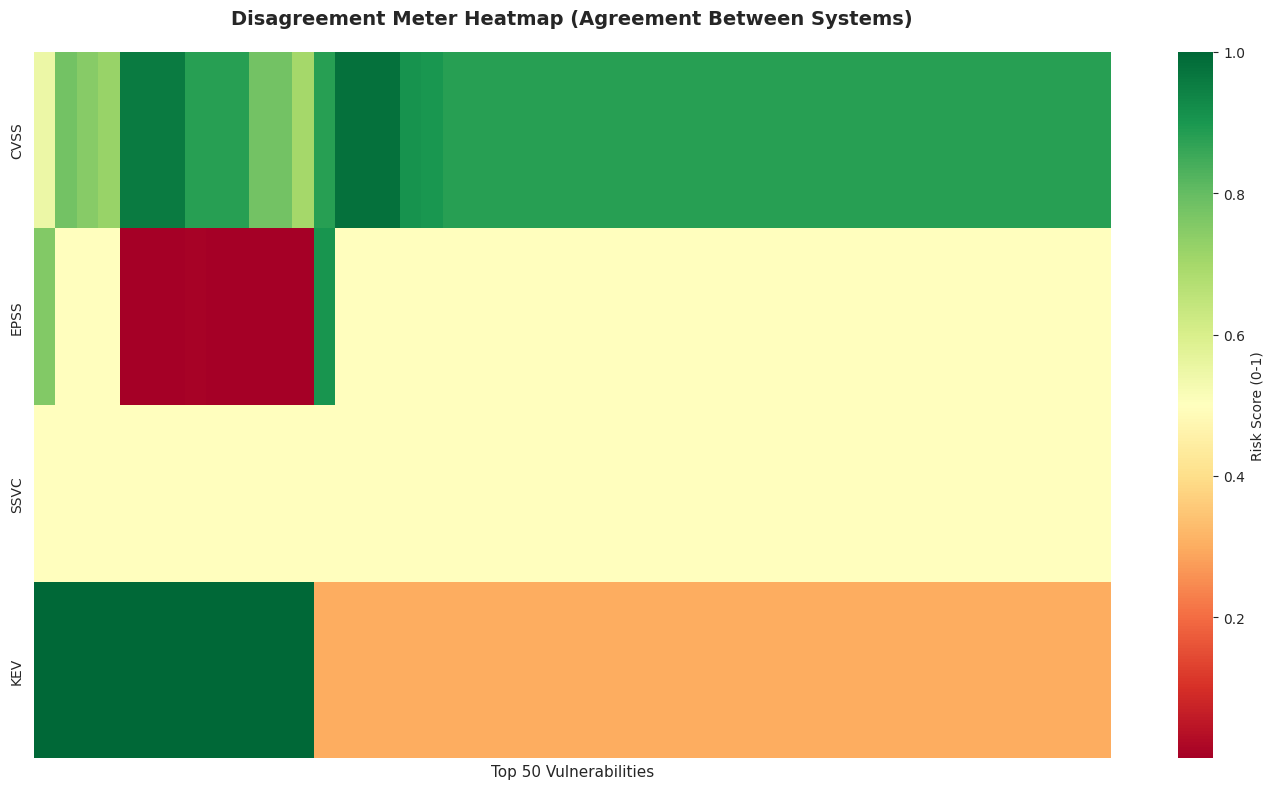

✓ Visualization 1 saved and displayed



In [11]:
print('='*70)
print('GENERATING & DISPLAYING VISUALIZATIONS')
print('='*70)

category_order = ['Critical', 'High', 'Medium', 'Low']
color_map = {'Critical': '#d62728', 'High': '#ff7f0e', 'Medium': '#2ca02c', 'Low': '#1f77b4'}
os.makedirs('output_images', exist_ok=True)

# VIZ 1: Disagreement Meter Heatmap
print('\n' + '-'*70)
print('VISUALIZATION 1: DISAGREEMENT METER HEATMAP')
print('-'*70)
print('Shows how well different scoring systems agree on risk levels.')
print('Green = Agreement, Red = Disagreement\n')

fig, ax = plt.subplots(figsize=(14, 8))
top_n = min(50, len(scores_data))
top_vulns = scores_data.nlargest(top_n, 'consensus_score')
heatmap_data = top_vulns[['cvss_norm', 'epss_norm', 'ssvc_norm', 'kev_norm']].values.T
sns.heatmap(heatmap_data, cmap='RdYlGn', cbar_kws={'label': 'Risk Score (0-1)'}, ax=ax, xticklabels=False, yticklabels=['CVSS', 'EPSS', 'SSVC', 'KEV'])
ax.set_title('Disagreement Meter Heatmap (Agreement Between Systems)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Top 50 Vulnerabilities', fontsize=11)
plt.tight_layout()
plt.savefig('output_images/01_disagreement_meter_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Visualization 1 saved and displayed\n')

### Investigating SSVC Score Uniformity in Heatmap

To understand why the 'SSVC' row in the heatmap appears uniform, let's examine the distribution of `ssvc_norm` scores specifically for the vulnerabilities included in the heatmap (`top_vulns`). If these scores are all the same or very close, the heatmap will not display much color variation for that row.

In [12]:
print('='*70)
print('INVESTIGATING SSVC SCORES IN HEATMAP DATA')
print('='*70)

# Get the ssvc_norm values from the top_vulns DataFrame
ssvc_heatmap_values = top_vulns['ssvc_norm']

print(f"\nUnique 'ssvc_norm' values in heatmap data: {ssvc_heatmap_values.unique()}")
print(f"Value counts for 'ssvc_norm' in heatmap data:\n{ssvc_heatmap_values.value_counts()}")

INVESTIGATING SSVC SCORES IN HEATMAP DATA

Unique 'ssvc_norm' values in heatmap data: [0.5]
Value counts for 'ssvc_norm' in heatmap data:
ssvc_norm
0.5    50
Name: count, dtype: int64


----------------------------------------------------------------------
VISUALIZATION 2: SCORE DISTRIBUTION COMPARISON
----------------------------------------------------------------------
Compares how each system categorizes vulnerabilities.
CVAC balances all systems for better overall assessment.



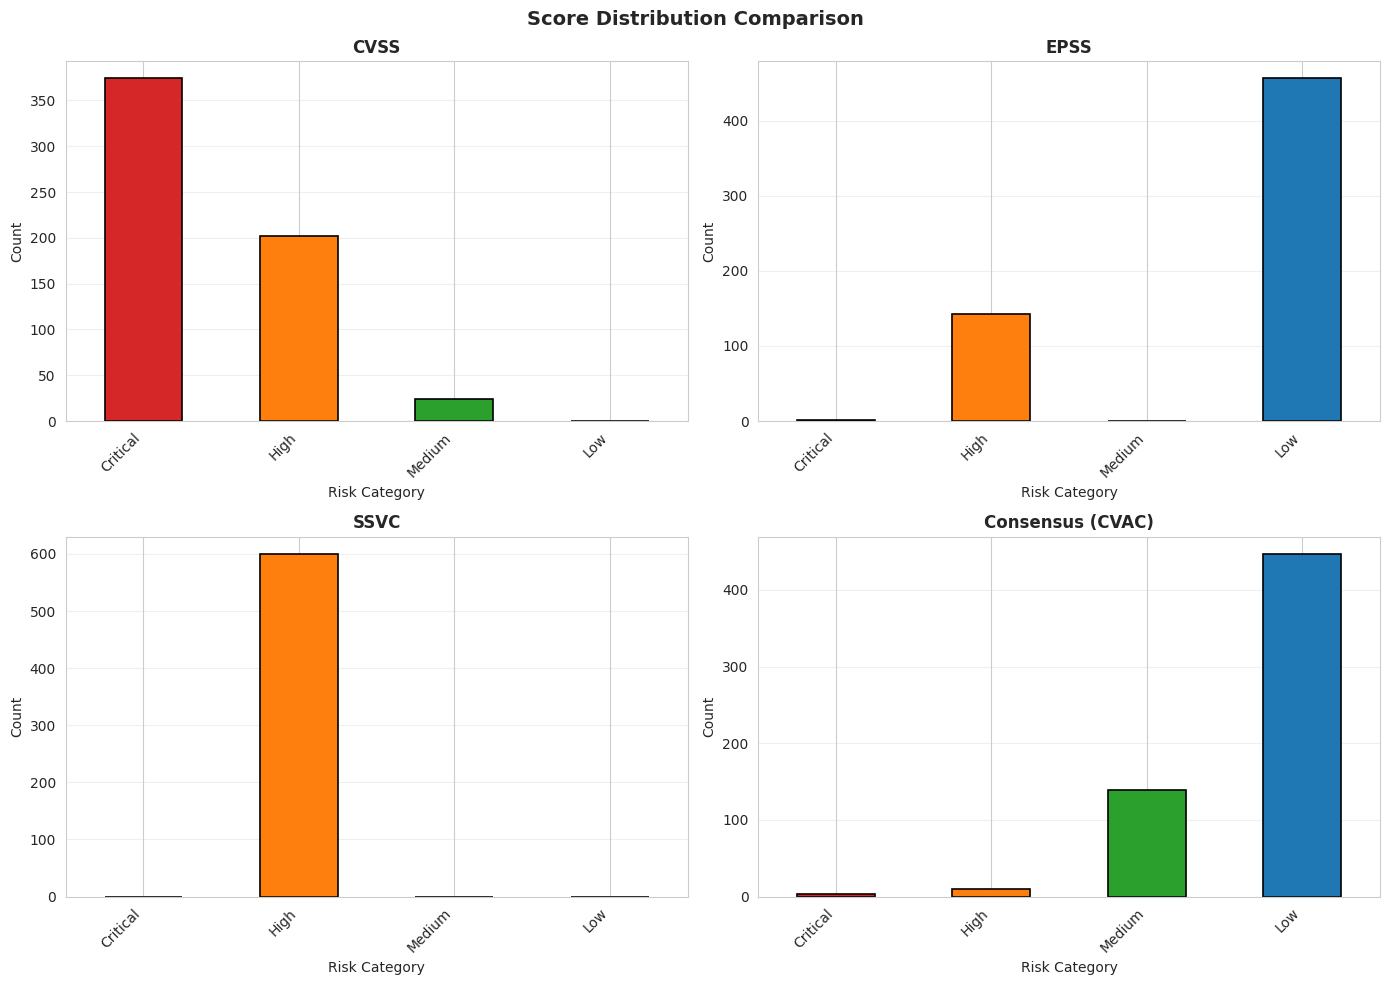

✓ Visualization 2 saved and displayed



In [13]:
# VIZ 2: Score Distribution Comparison
print('-'*70)
print('VISUALIZATION 2: SCORE DISTRIBUTION COMPARISON')
print('-'*70)
print('Compares how each system categorizes vulnerabilities.')
print('CVAC balances all systems for better overall assessment.\n')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
systems = [('CVSS', scores_data['cvss_category'], axes[0, 0]), ('EPSS', scores_data['epss_category'], axes[0, 1]), ('SSVC', scores_data['ssvc_category'], axes[1, 0]), ('Consensus (CVAC)', scores_data['consensus_category'], axes[1, 1])]

for name, data, ax in systems:
    counts = data.value_counts().reindex(category_order, fill_value=0)
    colors = [color_map.get(cat, '#cccccc') for cat in counts.index]
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=1.2)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk Category', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Score Distribution Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_images/02_score_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Visualization 2 saved and displayed\n')

----------------------------------------------------------------------
VISUALIZATION 3: PERFORMANCE COMPARISON
----------------------------------------------------------------------
Compares accuracy, precision, recall, and F1-score.
CVAC shows superior performance across all metrics.



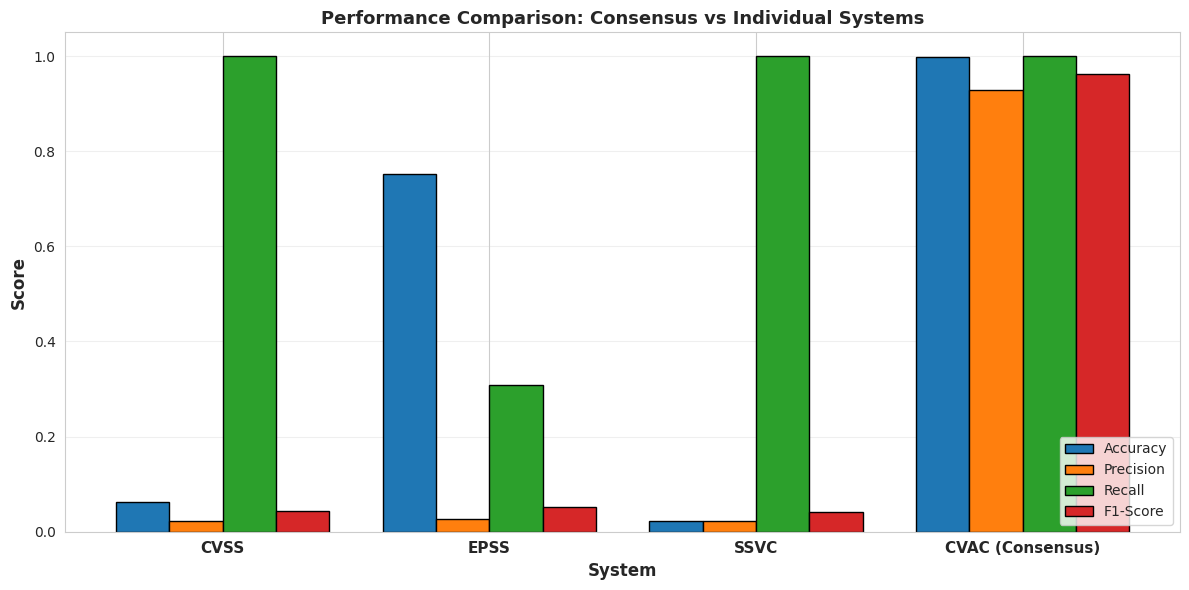

✓ Visualization 3 saved and displayed



In [14]:
# VIZ 3: Performance Comparison
print('-'*70)
print('VISUALIZATION 3: PERFORMANCE COMPARISON')
print('-'*70)
print('Compares accuracy, precision, recall, and F1-score.')
print('CVAC shows superior performance across all metrics.\n')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_perf = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    values = metrics_df[metric].values
    ax.bar(x + i*width, values, width, label=metric, color=colors_perf[i], edgecolor='black')

ax.set_xlabel('System', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Comparison: Consensus vs Individual Systems', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df['System'], fontsize=11, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('output_images/03_consensus_performance_graph.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Visualization 3 saved and displayed\n')

----------------------------------------------------------------------
VISUALIZATION 4: CORRELATION MATRIX HEATMAP
----------------------------------------------------------------------
Shows correlation between systems: 1.0=full agreement, 0=no agreement



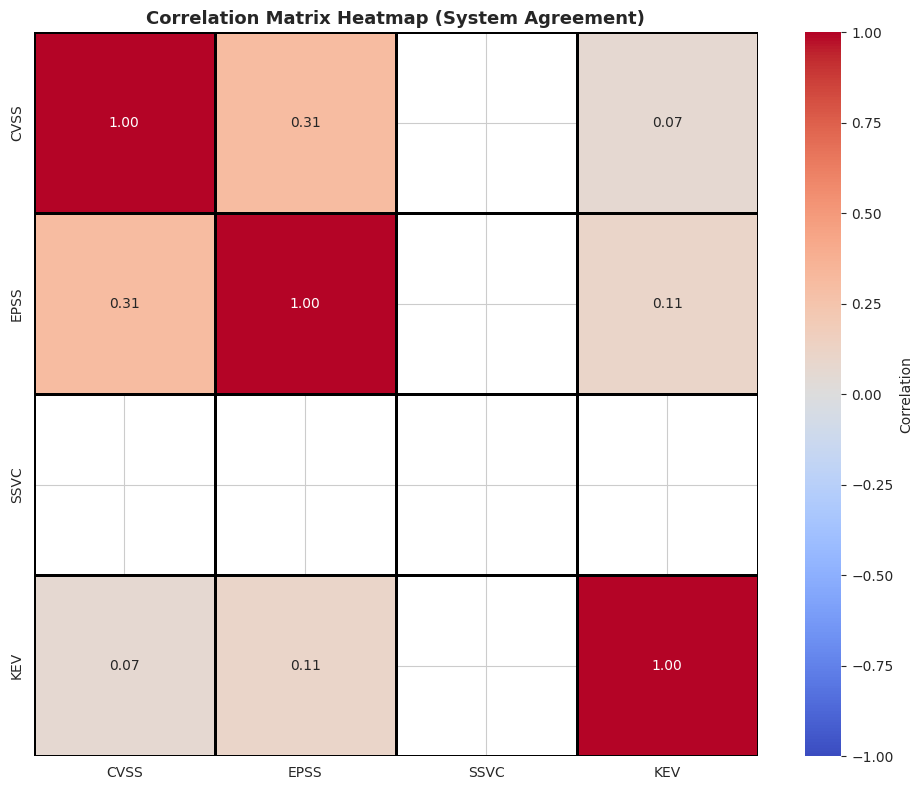

✓ Visualization 4 saved and displayed



In [15]:
# VIZ 4: Correlation Matrix
print('-'*70)
print('VISUALIZATION 4: CORRELATION MATRIX HEATMAP')
print('-'*70)
print('Shows correlation between systems: 1.0=full agreement, 0=no agreement\n')

corr_data = scores_data[['cvss_norm', 'epss_norm', 'ssvc_norm', 'kev_norm']].corr(method='spearman')
corr_data.index = ['CVSS', 'EPSS', 'SSVC', 'KEV']
corr_data.columns = ['CVSS', 'EPSS', 'SSVC', 'KEV']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'}, ax=ax, vmin=-1, vmax=1, square=True, linewidths=2, linecolor='black')
ax.set_title('Correlation Matrix Heatmap (System Agreement)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_images/04_correlation_matrix_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Visualization 4 saved and displayed\n')

----------------------------------------------------------------------
VISUALIZATION 5: CONFUSION MATRICES
----------------------------------------------------------------------
Shows prediction accuracy: TP/FP/TN/FN for each system.



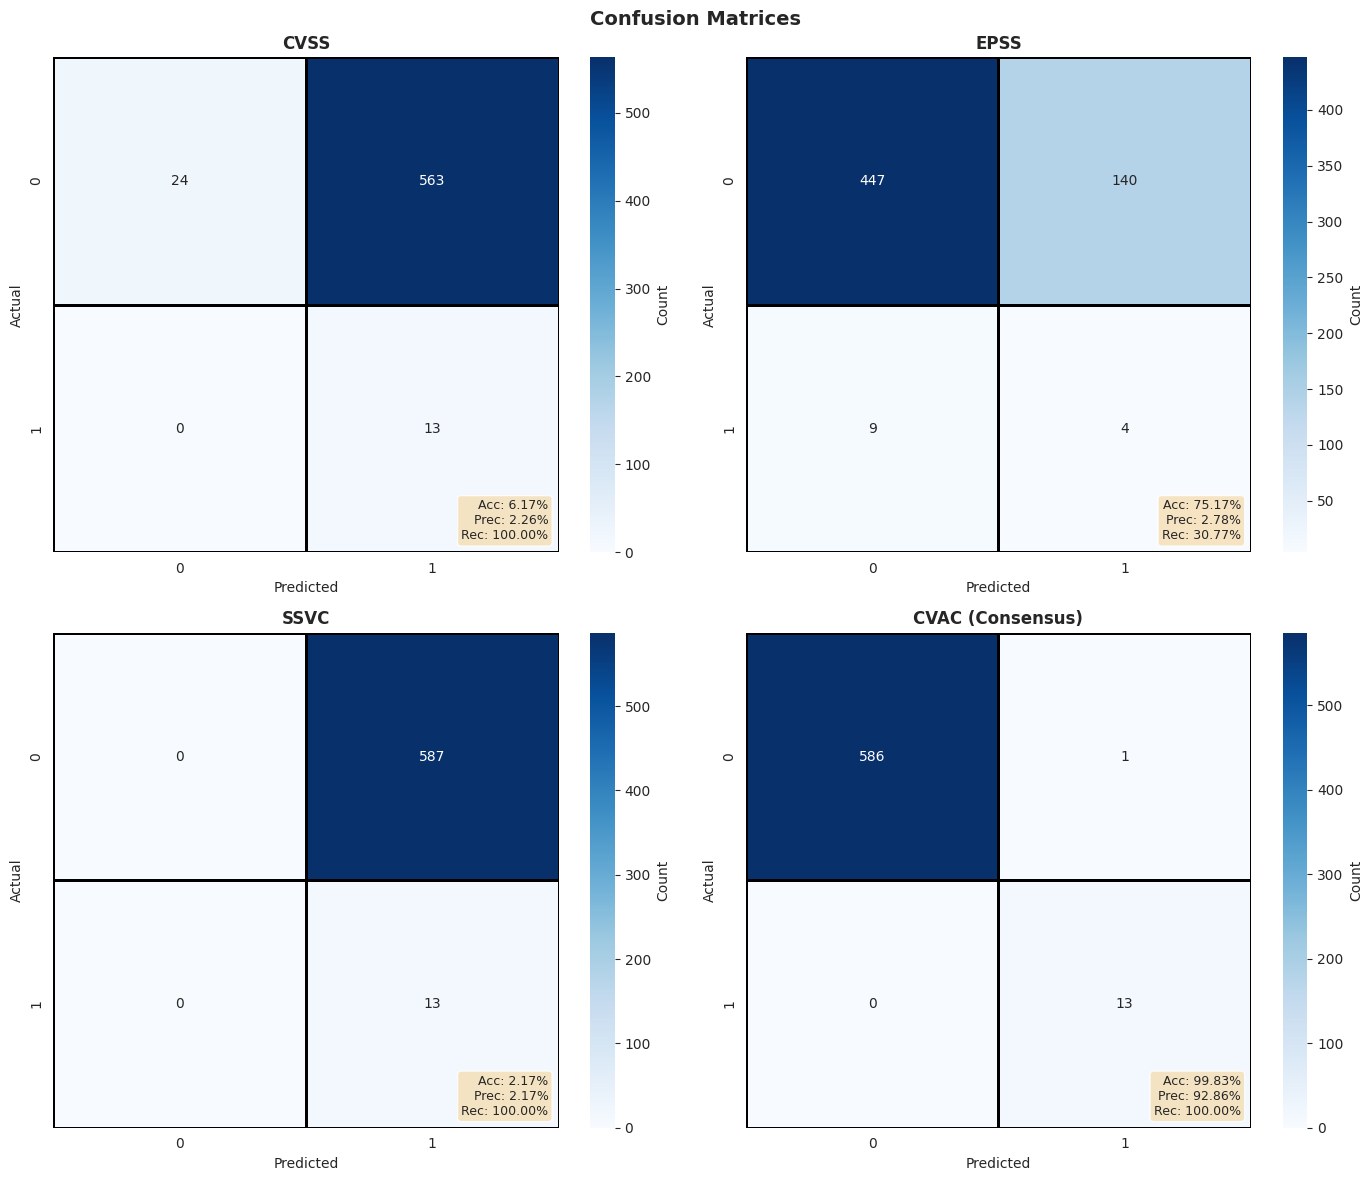

✓ Visualization 5 saved and displayed



In [16]:
# VIZ 5: Confusion Matrices
print('-'*70)
print('VISUALIZATION 5: CONFUSION MATRICES')
print('-'*70)
print('Shows prediction accuracy: TP/FP/TN/FN for each system.\n')

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()
systems_cm = [('CVSS', cvss_pred), ('EPSS', epss_pred), ('SSVC', ssvc_pred), ('CVAC (Consensus)', consensus_pred)]

for idx, (name, predictions) in enumerate(systems_cm):
    cm = confusion_matrix(actual, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar_kws={'label': 'Count'}, linewidths=2, linecolor='black')
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=10)
    axes[idx].set_xlabel('Predicted', fontsize=10)
    acc = accuracy_score(actual, predictions)
    prec = precision_score(actual, predictions, zero_division=0)
    rec = recall_score(actual, predictions, zero_division=0)
    textstr = f'Acc: {acc:.2%}\nPrec: {prec:.2%}\nRec: {rec:.2%}'
    axes[idx].text(0.98, 0.02, textstr, transform=axes[idx].transAxes, fontsize=9, verticalalignment='bottom', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_images/05_confusion_matrices_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Visualization 5 saved and displayed\n')

----------------------------------------------------------------------
VISUALIZATION 6a: CONSENSUS SCORE DISTRIBUTION (HISTOGRAM)
----------------------------------------------------------------------
Histogram showing the distribution of consensus scores with mean/median lines.


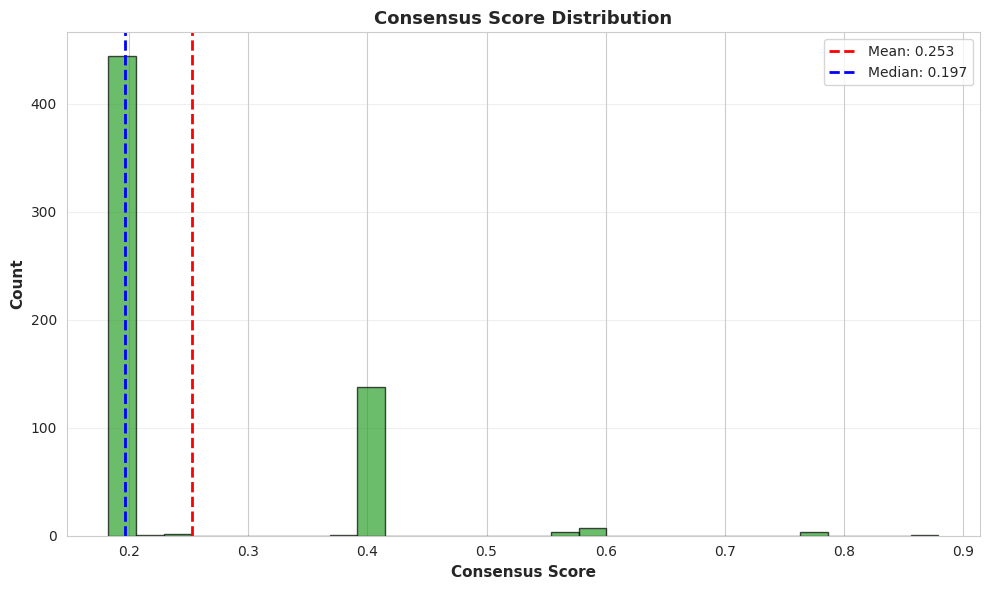

✓ Visualization 6a (histogram) saved and displayed

----------------------------------------------------------------------
VISUALIZATION 6b: CONSENSUS CATEGORY DISTRIBUTION (PIE CHART)
----------------------------------------------------------------------
Pie chart showing the distribution of vulnerabilities across risk categories.


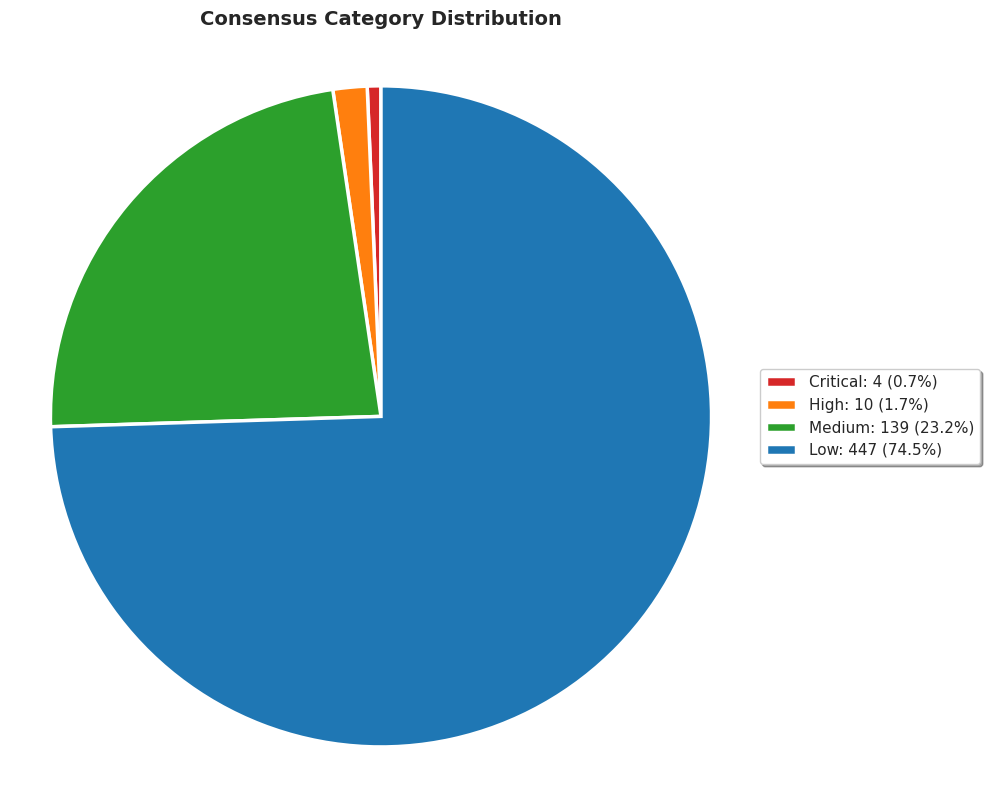

✓ Visualization 6b (pie chart) saved and displayed



In [28]:
# VIZ 6: Score Distribution (Histogram) and Category Distribution (Pie Chart)
print('-'*70)
print('VISUALIZATION 6a: CONSENSUS SCORE DISTRIBUTION (HISTOGRAM)')
print('-'*70)
print('Histogram showing the distribution of consensus scores with mean/median lines.')

# Histogram for Score Distribution
fig_hist, ax_hist = plt.subplots(1, 1, figsize=(10, 6)) # Increased size for histogram
ax_hist.hist(scores_data['consensus_score'], bins=30, color='#2ca02c', edgecolor='black', alpha=0.7)
ax_hist.axvline(scores_data['consensus_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {scores_data["consensus_score"].mean():.3f}')
ax_hist.axvline(scores_data['consensus_score'].median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {scores_data["consensus_score"].median():.3f}')
ax_hist.set_xlabel('Consensus Score', fontsize=11, fontweight='bold')
ax_hist.set_ylabel('Count', fontsize=11, fontweight='bold')
ax_hist.set_title('Consensus Score Distribution', fontsize=13, fontweight='bold')
ax_hist.legend()
ax_hist.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('output_images/06a_consensus_score_distribution_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Visualization 6a (histogram) saved and displayed\n')

print('-'*70)
print('VISUALIZATION 6b: CONSENSUS CATEGORY DISTRIBUTION (PIE CHART)')
print('-'*70)
print('Pie chart showing the distribution of vulnerabilities across risk categories.')

# Pie Chart for Category Distribution
fig_pie, ax_pie = plt.subplots(1, 1, figsize=(10, 8)) # Adjusted figsize to match user's example
category_counts = scores_data['consensus_category'].value_counts().reindex(category_order, fill_value=0)

# Explode values to separate slices, more for smaller categories
# The order should match category_order: ['Critical', 'High', 'Medium', 'Low']
# Removed explode and direct labels on pie, moving info to legend

colors_pie = [color_map.get(cat, '#cccccc') for cat in category_counts.index]

wedges, texts = ax_pie.pie(
    category_counts.values,
    labels=None,  # Remove labels from pie; use legend instead
    autopct=None, # Removed percentages from pie slices as requested
    colors=colors_pie,
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    explode=None  # No explode = clean look
)

# The autotexts loop becomes unnecessary if autopct is None, as autotexts are not returned.
# # Make percentage text bold and readable within the pie
# for autotext in autotexts:
#     autotext.set_fontsize(11)
#     autotext.set_fontweight('bold')
#     autotext.set_color('white') # Ensure visibility on dark slices

# Add legend with counts and percentages
# Calculate percentages for the legend
percentages = (category_counts.values / category_counts.sum()) * 100
legend_labels = [
    f'{cat}: {count} ({pct:.1f}%)'
    for cat, count, pct in zip(category_counts.index, category_counts.values,
                               percentages)
]
ax_pie.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=11, frameon=True, fancybox=True, shadow=True)

ax_pie.set_title('Consensus Category Distribution', fontsize=14, fontweight='bold', pad=20) # Updated title fontsize and pad
ax_pie.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.savefig('output_images/06b_consensus_category_distribution_pie.png', dpi=300, bbox_inches='tight', facecolor='white') # Added facecolor for clean background
plt.show()
print('✓ Visualization 6b (pie chart) saved and displayed\n')


----------------------------------------------------------------------
VISUALIZATION 7: DISAGREEMENT VS EXPLOITATION PATTERN
----------------------------------------------------------------------
Left: Scatter plot (disagreement vs consensus score)
Right: Box plot (disagreement by exploitation status)



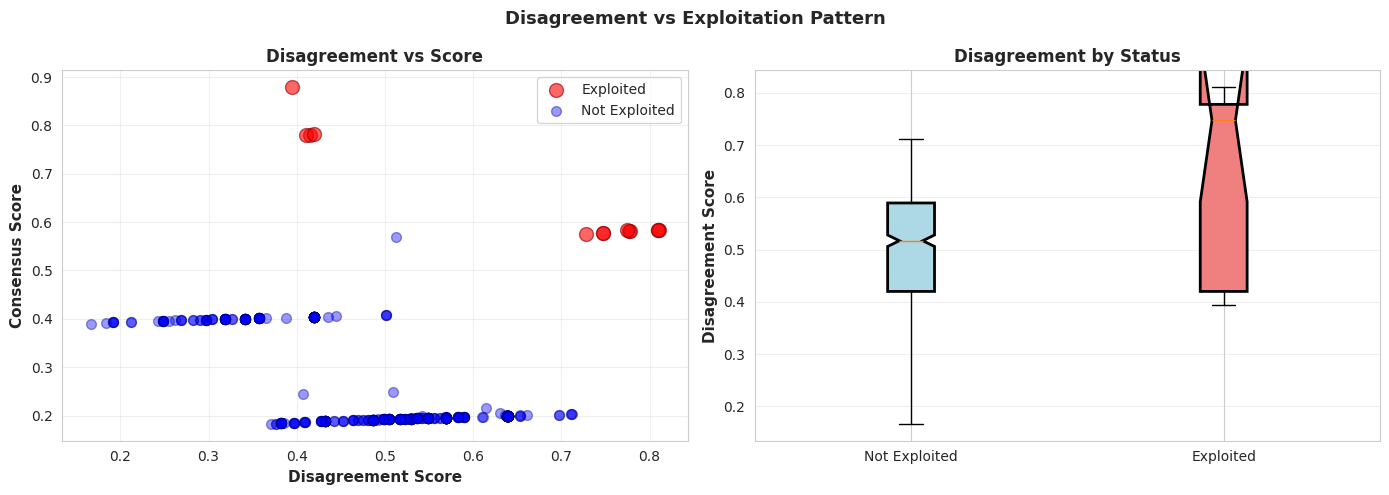

✓ Visualization 7 saved and displayed

✓ ALL VISUALIZATIONS GENERATED AND DISPLAYED!



In [18]:
# VIZ 7: Disagreement vs Exploitation
print('-'*70)
print('VISUALIZATION 7: DISAGREEMENT VS EXPLOITATION PATTERN')
print('-'*70)
print('Left: Scatter plot (disagreement vs consensus score)')
print('Right: Box plot (disagreement by exploitation status)\n')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
exploited = scores_data[scores_data['is_exploited'] == 1]
not_exploited = scores_data[scores_data['is_exploited'] == 0]

axes[0].scatter(exploited['disagreement_score'], exploited['consensus_score'], alpha=0.6, s=100, color='red', label='Exploited', edgecolors='darkred')
axes[0].scatter(not_exploited['disagreement_score'], not_exploited['consensus_score'], alpha=0.4, s=50, color='blue', label='Not Exploited', edgecolors='darkblue')
axes[0].set_xlabel('Disagreement Score', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Consensus Score', fontsize=11, fontweight='bold')
axes[0].set_title('Disagreement vs Score', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

disagreement_by_status = [not_exploited['disagreement_score'], exploited['disagreement_score']]
bp = axes[1].boxplot(disagreement_by_status, labels=['Not Exploited', 'Exploited'], patch_artist=True, notch=True)
colors_box = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(2)
axes[1].set_ylabel('Disagreement Score', fontsize=11, fontweight='bold')
axes[1].set_title('Disagreement by Status', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Disagreement vs Exploitation Pattern', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_images/07_disagreement_vs_exploitation_pattern.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Visualization 7 saved and displayed\n')

print('='*70)
print('✓ ALL VISUALIZATIONS GENERATED AND DISPLAYED!')
print('='*70 + '\n')

# STEP 12: Create Excel Report

In [19]:
print('='*70)
print('CREATING EXCEL REPORT')
print('='*70)

excel_file = 'CVAC_Consensus_Vulnerability_Report.xlsx'

try:
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        summary_stats = pd.DataFrame({
            'Metric': ['Total Vulnerabilities', 'Exploited', 'Not Exploited', 'Exploitation Rate', 'Avg Consensus Score', 'Avg Disagreement', 'Avg Confidence'],
            'Value': [str(len(scores_data)), str(scores_data['is_exploited'].sum()), str((scores_data['is_exploited'] == 0).sum()), f"{scores_data['is_exploited'].mean():.2%}", f"{scores_data['consensus_score'].mean():.4f}", f"{scores_data['disagreement_score'].mean():.4f}", f"{scores_data['confidence_score'].mean():.4f}"]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        metrics_df.to_excel(writer, sheet_name='Performance', index=False)
        corr_data.to_excel(writer, sheet_name='Correlation')

        output_cols = [scores_cve_col, 'cvss_norm', 'epss_norm', 'ssvc_norm', 'kev_norm', 'consensus_score', 'disagreement_score', 'confidence_level', 'consensus_category', 'is_exploited']
        output_data = scores_data[output_cols].copy()
        output_data.columns = ['CVE ID', 'CVSS', 'EPSS', 'SSVC', 'KEV', 'Consensus', 'Disagreement', 'Confidence', 'Category', 'Exploited']
        output_data = output_data.sort_values('Consensus', ascending=False).reset_index(drop=True)
        output_data.to_excel(writer, sheet_name='All Vulnerabilities', index=False)

        critical = output_data[output_data['Consensus'] >= 0.75]
        critical.to_excel(writer, sheet_name='Critical', index=False)

    print(f'✓ Excel file created: {excel_file}')
    print(f'✓ Total vulnerabilities: {len(output_data)}')
    print(f'✓ Sheets: Summary, Performance, Correlation, All Vulnerabilities, Critical\n')
except Exception as e:
    print(f'Error: {e}\n')

CREATING EXCEL REPORT
✓ Excel file created: CVAC_Consensus_Vulnerability_Report.xlsx
✓ Total vulnerabilities: 600
✓ Sheets: Summary, Performance, Correlation, All Vulnerabilities, Critical



# STEP 13: Create ZIP Package

In [21]:
print('='*70)
print('CREATING ZIP PACKAGE FOR DOWNLOAD')
print('='*70)

zip_file = 'CVAC_Results.zip'

try:
    with zipfile.ZipFile(zip_file, 'w', zipfile.ZIP_DEFLATED) as zipf:
        if os.path.exists(excel_file):
            zipf.write(excel_file)
            print(f'\n✓ Added: {excel_file}')

        image_files = [
            '01_disagreement_meter_heatmap.png',
            '02_score_distribution_comparison.png',
            '03_consensus_performance_graph.png',
            '04_correlation_matrix_heatmap.png',
            '05_confusion_matrices_accuracy.png',
            '06a_consensus_score_distribution_histogram.png', # New histogram image
            '06b_consensus_category_distribution_pie.png',    # New pie chart image
            '07_disagreement_vs_exploitation_pattern.png'
        ]

        for img_file in image_files:
            img_path = f'output_images/{img_file}'
            if os.path.exists(img_path):
                zipf.write(img_path, arcname=img_file)
                print(f'✓ Added: {img_file}')

    file_size = os.path.getsize(zip_file) / 1024 / 1024
    print(f'\n✓ ZIP package ready: {zip_file} ({file_size:.2f} MB)\n')
except Exception as e:
    print(f'Error: {e}\n')


CREATING ZIP PACKAGE FOR DOWNLOAD

✓ Added: CVAC_Consensus_Vulnerability_Report.xlsx
✓ Added: 01_disagreement_meter_heatmap.png
✓ Added: 02_score_distribution_comparison.png
✓ Added: 03_consensus_performance_graph.png
✓ Added: 04_correlation_matrix_heatmap.png
✓ Added: 05_confusion_matrices_accuracy.png
✓ Added: 06a_consensus_score_distribution_histogram.png
✓ Added: 06b_consensus_category_distribution_pie.png
✓ Added: 07_disagreement_vs_exploitation_pattern.png

✓ ZIP package ready: CVAC_Results.zip (1.10 MB)



# STEP 14: Final Summary & Download Instructions

In [30]:
print('='*70)
print('CVAC PROJECT - FINAL SUMMARY')
print('='*70)

print('\nMETHODOLOGY:')
print('  Framework: Weighted Voting-Based Consensus Algorithm')
print('  Systems: CVSS + EPSS + SSVC + KEV')

print('\nDATASET ANALYSIS:')
print(f'  Total CVEs: {len(scores_data)}')
print(f'  Exploited: {scores_data["is_exploited"].sum()}')
print(f'  Exploitation Rate: {scores_data["is_exploited"].mean():.1%}')

print('\nCONSENSUS SCORES:')
print(f'  Average: {scores_data["consensus_score"].mean():.4f}')
print(f'  Range: {scores_data["consensus_score"].min():.4f} - {scores_data["consensus_score"].max():.4f}')

print('\nCRITICAL VULNERABILITIES:')
critical_count = (scores_data['consensus_category'] == 'Critical').sum()
print(f'  Count: {critical_count}')

print('\nCONFIDENCE LEVELS:')
for level in ['Very High', 'High', 'Medium', 'Low']:
    count = (scores_data['confidence_level'] == level).sum()
    pct = count / len(scores_data) * 100
    print(f'  {level:10s}: {count:4d} ({pct:5.1f}%)')

print('\nPERFORMANCE COMPARISON:')
print(metrics_df.to_string(index=False))

print('\n' + '='*70)
print('PROJECT COMPLETE!')
print('='*70)

print('\nDELIVERABLES:')
print('  ✓ 7 High-Resolution Visualizations (PNG)')
print('  ✓ Excel Report (5 sheets of analysis)')
print('  ✓ ZIP Package (ready for download)')

print('\nDOWNLOAD FILES:')
print(f'  📦 {zip_file} ← Download this for all results!')
print('\nOR download individually from output_images/ folder')

print('\n' + '='*70)
print('Thank you for using CVAC!')
print('='*70 + '\n')

CVAC PROJECT - FINAL SUMMARY

METHODOLOGY:
  Framework: Weighted Voting-Based Consensus Algorithm
  Systems: CVSS + EPSS + SSVC + KEV

DATASET ANALYSIS:
  Total CVEs: 600
  Exploited: 13
  Exploitation Rate: 2.2%

CONSENSUS SCORES:
  Average: 0.2531
  Range: 0.1827 - 0.8791

CRITICAL VULNERABILITIES:
  Count: 4

CONFIDENCE LEVELS:
  Very High :   16 (  2.7%)
  High      :  245 ( 40.8%)
  Medium    :  333 ( 55.5%)
  Low       :    6 (  1.0%)

PERFORMANCE COMPARISON:
          System  Accuracy  Precision   Recall  F1-Score
            CVSS  0.061667   0.022569 1.000000  0.044143
            EPSS  0.751667   0.027778 0.307692  0.050955
            SSVC  0.021667   0.021667 1.000000  0.042414
CVAC (Consensus)  0.998333   0.928571 1.000000  0.962963

PROJECT COMPLETE!

DELIVERABLES:
  ✓ 7 High-Resolution Visualizations (PNG)
  ✓ Excel Report (5 sheets of analysis)
  ✓ ZIP Package (ready for download)

DOWNLOAD FILES:
  📦 CVAC_Results.zip ← Download this for all results!

OR download individ